# Size-Effect -- the quant teardown
### Cap-ranking, dollar- vs beta-neutral spreads, placebo, decay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![January concentration%3F: Busted](https://img.shields.io/badge/January--concentration%3F-Busted-8b949e?style=flat-square)

Protocol: each month-end rank a 40-name survivor basket by market cap (`cap_t = cap_now * price_t / price_now`, shares-constant), long the small half / short the large half, **one execution lag** (signal month *m* -> return month *m+1*). Dollar-neutral and beta-neutral books, costs + short borrow, a label-shuffle placebo, and an early-vs-late decay slice.

> Companion plain-language notebook: **[01_for_the_curious.ipynb](01_for_the_curious.ipynb)**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from size_effect import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    c = os.path.join(study, "_cache")
    return all(os.path.exists(os.path.join(c, f)) for f in
               ("size_prices.parquet", "size_spy.parquet", "size_caps.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy, caps = data.fetch_panel()
    book = st.add_beta_neutral(st.smb_portfolio(prices, spy, caps, min_stocks=10))
    book = data.drop_partial_last_month(book)
    s_dn = st.summary(book["smb_dn"]); s_bn = st.summary(book["smb_bn"])
    print(f"N months: {s_dn['n']} | SMB dollar-neutral: {s_dn['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_dn['tstat']:+.3f}")


yfinance cache present: True


N months: 304 | SMB dollar-neutral: -1.08%/yr | HAC t: -0.483


## The spreads -- gross, beta-neutral, and net of costs

Hedging out market beta (ratio ~0.97 -- small and large were near-equal beta on this basket) does not rescue the book; costs only deepen the hole.

In [2]:
if HAVE_REAL:
    net = st.apply_costs(book['smb_dn'], book['turnover'], 10.0, 100.0)
    rows = [('Dollar-neutral, gross', st.summary(book['smb_dn'])),
            ('Beta-neutral, gross', st.summary(book['smb_bn'])),
            ('Dollar-neutral, net', st.summary(net))]
    for name, s in rows:
        print(f'{name:28s} mean {s["mean"]*100:+6.2f}%/yr  '
              f'Sharpe {s["sharpe"]:+.3f}  HAC t {s["tstat"]:+.3f}')
    print(f'Avg beta-hedge ratio: {book["beta_ratio"].mean():.3f}  | '
          f'avg turnover: {book["turnover"].mean()*100:.1f}%/mo')
else:
    print(f'Dollar-neutral gross  mean {R["dn_mean"]:+.2f}%/yr  HAC t {R["dn_t"]:+.3f}')
    print(f'Beta-neutral   gross  mean {R["bn_mean"]:+.2f}%/yr  HAC t {R["bn_t"]:+.3f}')
    print(f'Dollar-neutral net    mean {R["net_mean"]:+.2f}%/yr  HAC t {R["net_t"]:+.3f}')

Dollar-neutral, gross        mean  -1.08%/yr  Sharpe -0.090  HAC t -0.483
Beta-neutral, gross          mean  -1.76%/yr  Sharpe -0.146  HAC t -0.755
Dollar-neutral, net          mean  -2.08%/yr  Sharpe -0.173  HAC t -0.933
Avg beta-hedge ratio: 0.967  | avg turnover: 0.4%/mo


## Equity curve & drawdown -- the small-minus-large book

A self-financing SMB book on this basket is a slow grind *down*.

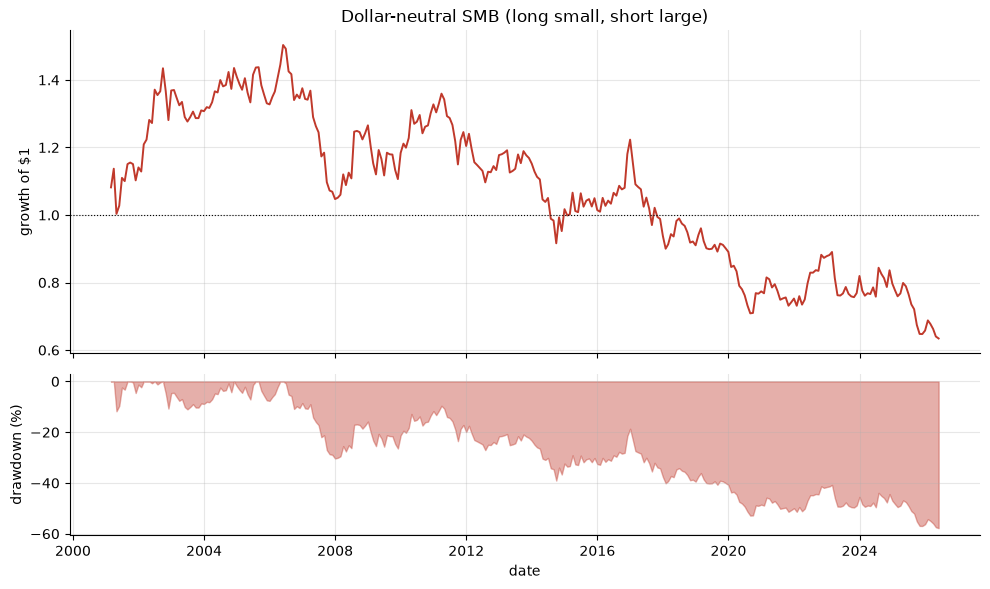

Terminal multiple: 0.63x | max DD -57.8%


In [3]:
if HAVE_REAL:
    eq = (1 + book['smb_dn']).cumprod()
    dd = eq / eq.cummax() - 1
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})
    a1.plot(eq.index, eq.values, c=RED, lw=1.4)
    a1.axhline(1.0, c='k', lw=0.8, ls=':'); a1.set_ylabel('growth of $1')
    a1.set_title('Dollar-neutral SMB (long small, short large)')
    a2.fill_between(dd.index, dd.values*100, 0, color=RED, alpha=0.4)
    a2.set_ylabel('drawdown (%)'); a2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    print(f'Terminal multiple: {eq.iloc[-1]:.2f}x | max DD {dd.min()*100:.1f}%')
else:
    print(f'Frozen: dollar-neutral {R["dn_mean"]:+.2f}%/yr, max DD {R["dn_dd"]:.1f}%')

## The label-shuffle placebo

Re-assign the small/large labels at random each month (preserving the 20/20 split) and recompute the HAC *t*, 300 times. If the size *label* carries information, the real *t* should sit in the tail of this null. It does not.

In [4]:
if HAVE_REAL:
    t_real, p = st.placebo_pvalue(prices, spy, caps, n_perm=200, min_stocks=10)
    print(f'Real DN HAC t = {t_real:+.3f}')
    print(f'Placebo p (|t_null| >= |t_real|) = {p:.3f}')
else:
    print(f'Frozen: real t = {R["placebo_t"]:+.3f}, placebo p = {R["placebo_p"]:.3f}')
print('\nThe size label is indistinguishable from a random coin-flip label.')

Real DN HAC t = -0.483
Placebo p (|t_null| >= |t_real|) = 0.625

The size label is indistinguishable from a random coin-flip label.


## Decay within sample -- early vs late

Data begins 2001, so we split the sample at its midpoint. The small tilt that was mildly positive early flips negative in the mega-cap-led second half -- the well-documented post-publication / post-1980 size decay (Schwert 2003).

In [5]:
if HAVE_REAL:
    dec = st.decade_split(book, cut='2013-07-01')
    print(f"Early 2001-2013: {dec['pre_mean_ann']*100:+.2f}%/yr  "
          f"HAC t {dec['pre_t']:+.3f}  (n={dec['pre_n']})")
    print(f"Late  2013-2026: {dec['post_mean_ann']*100:+.2f}%/yr  "
          f"HAC t {dec['post_t']:+.3f}  (n={dec['post_n']})")
else:
    print(f"Early 2001-2013: {R['early_mean']:+.2f}%/yr  HAC t {R['early_t']:+.3f}")
    print(f"Late  2013-2026: {R['late_mean']:+.2f}%/yr  HAC t {R['late_t']:+.3f}")

Early 2001-2013: +1.76%/yr  HAC t +0.556  (n=149)
Late  2013-2026: -3.81%/yr  HAC t -1.245  (n=155)


## Survivorship & limitations

- **Survivorship bias (named).** The basket is names still trading in 2026. Failed small-caps -- the natural *long* leg -- are absent, biasing the size premium **upward**. It is *still* negative here, so the true premium is no better.
- **Cap reconstruction.** `cap_t = cap_now * price_t / price_now` holds shares outstanding constant (ignores buybacks/issuance). Adequate for *ranking* a stable basket into small/large halves; it would matter more for a value-weighted book.
- **Basket size.** 40 names is a thin cross-section vs the thousands Banz used; the median split gives only 20-a-side. This is a *replication on retail-pullable data*, not the CRSP universe.
- **Quality control.** Asness et al. (2018) show the size premium re-emerges only after controlling for quality (junk small-caps drag it). We do **not** control for quality -- a documented reason the raw effect looks dead.

*Think size survives once you add the missing small-caps and a quality screen? Fork this, expand to the Russell 2000 with delisted names, sort within quality buckets, and show *t* > 2 net of costs. That is the bar.*